📊 '경사도'를 포함한 핵심 변수 종합 EDA 대시보드를 생성합니다...


C:\Users\junse\AppData\Local\Temp\ipykernel_27068\3000191554.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y=target, data=plot_data, ax=ax, palette='Set2')
C:\Users\junse\AppData\Local\Temp\ipykernel_27068\3000191554.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y=target, data=plot_data, ax=ax, palette='Set2')
C:\Users\junse\AppData\Local\Temp\ipykernel_27068\3000191554.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=var, y=target, data=plot_data, ax=ax, palette='Set2')
C:\Users\junse\AppData\Local\Temp\ipy

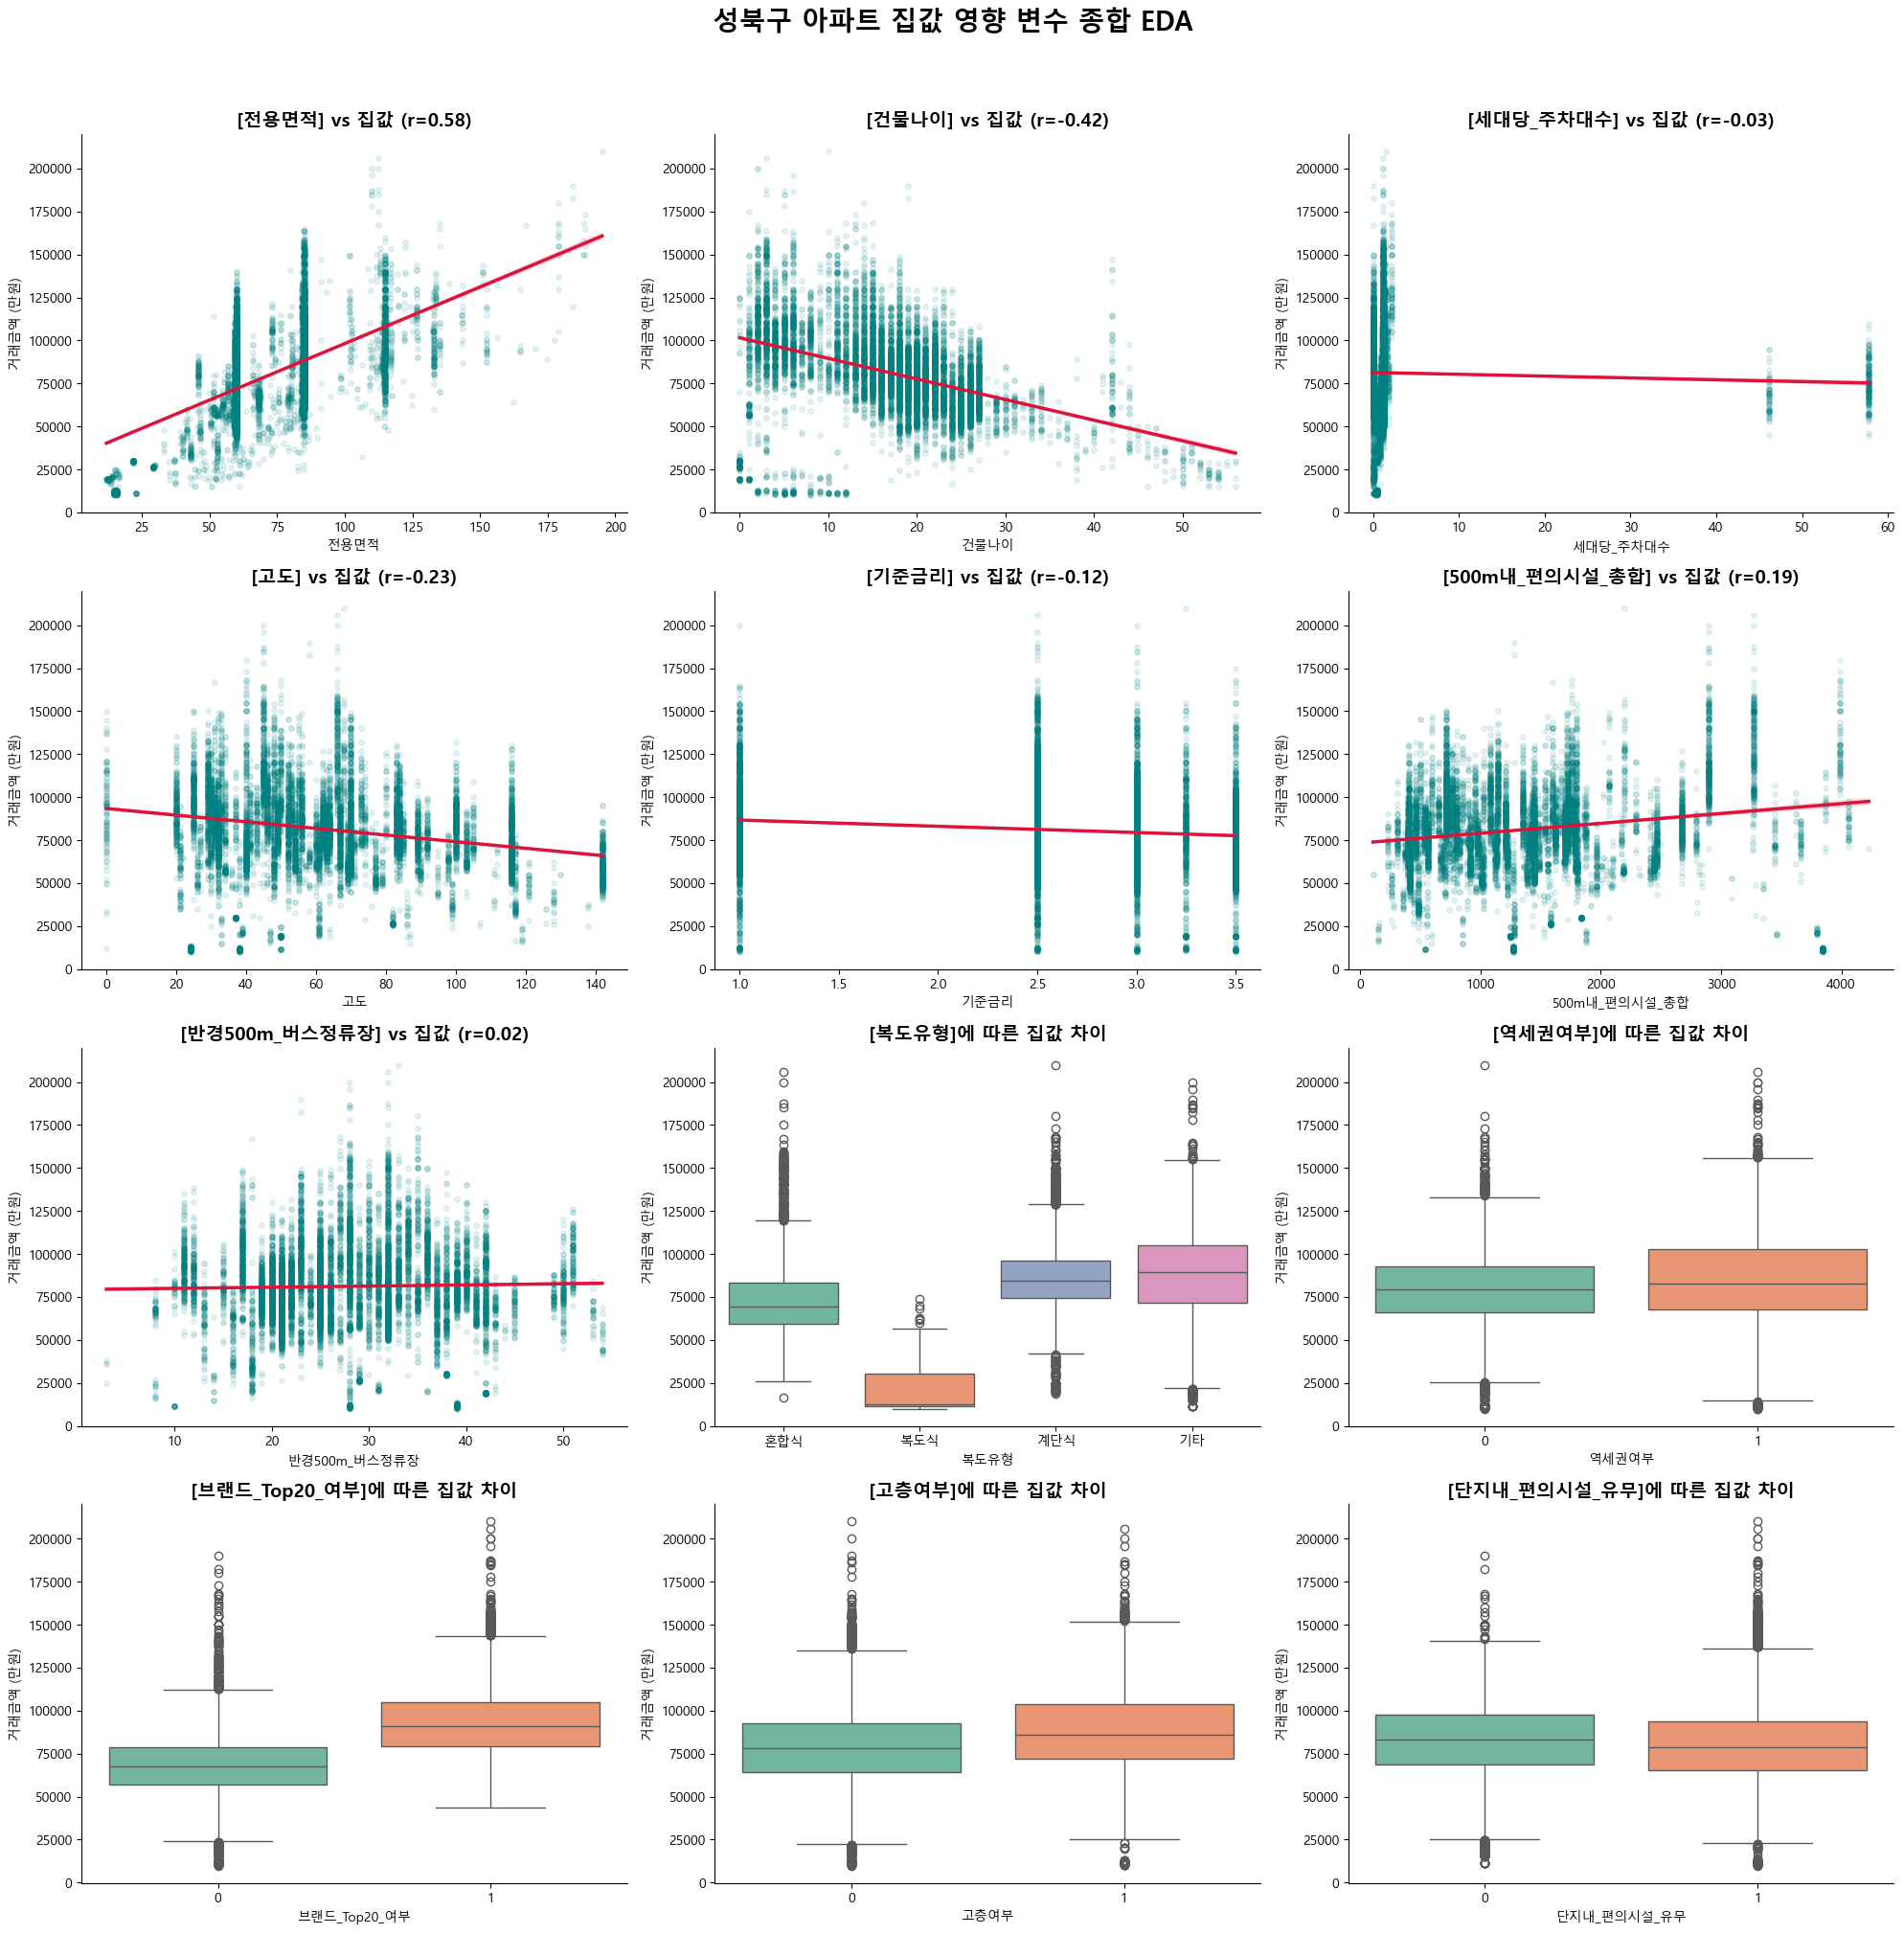

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 1. 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

print("📊 '경사도'를 포함한 핵심 변수 종합 EDA 대시보드를 생성합니다...")

# 2. 파일 불러오기
df = pd.read_csv('final_dataset.csv', low_memory=False)

# 단지내_편의시설_유무 생성
if '부대복리시설' in df.columns and '단지내_편의시설_유무' not in df.columns:
    df['단지내_편의시설_유무'] = df['부대복리시설'].apply(lambda x: 0 if pd.isna(x) or str(x).strip().lower() == 'nan' else 1)

if '복도유형' in df.columns:
    df['복도유형'] = df['복도유형'].astype(str).str.strip() 
    df.loc[~df['복도유형'].isin(['계단식', '복도식', '혼합식']), '복도유형'] = '기타'

# 3. EDA를 진행할 타겟 변수와 분석 대상 변수 리스트
target = '거래금액_만원'
features = [
    '전용면적', '건물나이', '세대당_주차대수', '고도', '기준금리', 
    '500m내_편의시설_총합', '반경500m_버스정류장', '경사도', # <- 경사도 부활!
    '복도유형', '역세권여부', '브랜드_Top20_여부', '고층여부', '단지내_편의시설_유무'
]

valid_features = [f for f in features if f in df.columns]

fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(20, 24))
axes = axes.flatten()

categorical_vars = ['복도유형', '역세권여부', '브랜드_Top20_여부', '고층여부', '단지내_편의시설_유무']

for i, var in enumerate(valid_features):
    ax = axes[i]
    
    plot_data = df.dropna(subset=[var, target]).copy()
    
    if var in categorical_vars:
        sns.boxplot(x=var, y=target, data=plot_data, ax=ax, palette='Set2')
        ax.set_title(f'[{var}]에 따른 집값 차이', fontsize=14, fontweight='bold')
    else:
        sns.regplot(x=var, y=target, data=plot_data, ax=ax, 
                    scatter_kws={'alpha':0.1, 'color':'teal', 's':15}, 
                    line_kws={'color':'crimson', 'linewidth':2.5})
        
        if plot_data[var].nunique() > 1:
            corr = plot_data[var].corr(plot_data[target])
            ax.set_title(f'[{var}] vs 집값 (r={corr:.2f})', fontsize=14, fontweight='bold')
        else:
            ax.set_title(f'[{var}] vs 집값 (변화 없음)', fontsize=14, fontweight='bold')
        
    ax.set_ylabel('거래금액 (만원)')
    ax.set_xlabel(var)
    
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

for j in range(len(valid_features), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('성북구 아파트 집값 영향 변수 종합 EDA', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

랜덤 포레스트 학습을 시작합니다...
모델 예측 정확도 (R2 Score) : 0.9252


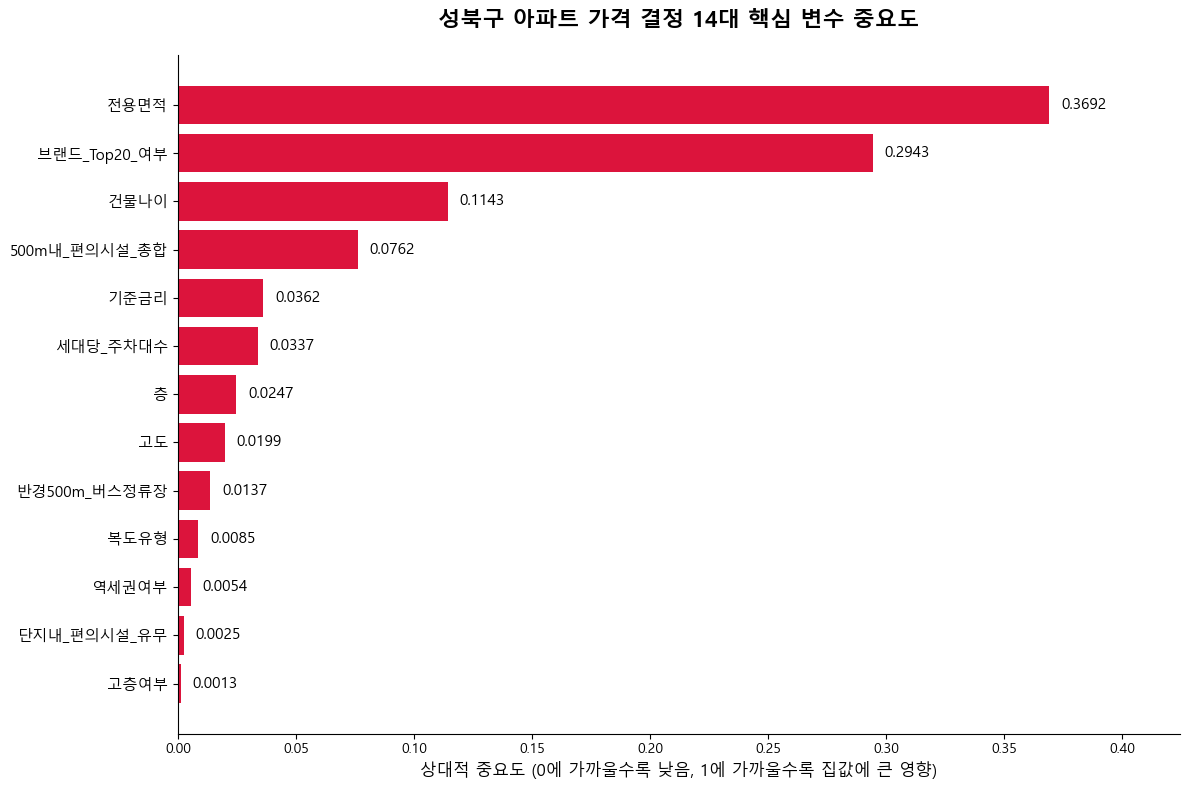

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score
import platform
import warnings

warnings.filterwarnings('ignore')

# 1. 폰트 및 시각화 기본 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin':
    plt.rc('font', family='AppleGothic')
plt.rcParams['axes.unicode_minus'] = False

# 2. 데이터 불러오기 및 안전 전처리
df = pd.read_csv('final_dataset.csv', low_memory=False)

# 단지내 편의시설 유무
if '단지내_편의시설_유무' not in df.columns and '부대복리시설' in df.columns:
    df['단지내_편의시설_유무'] = df['부대복리시설'].apply(
        lambda x: 0 if pd.isna(x) or str(x).strip().lower() == 'nan' else 1
    )

# 복도유형 정제 및 라벨 인코딩
if '복도유형' in df.columns:
    df['복도유형'] = df['복도유형'].astype(str).str.strip() 
    df.loc[~df['복도유형'].isin(['계단식', '복도식', '혼합식']), '복도유형'] = '기타'
    
    le = LabelEncoder()
    df['복도유형_인코딩'] = le.fit_transform(df['복도유형'])

# 3. 독립변수(X)와 종속변수(y) 설정 
features = [
    '전용면적', '건물나이', '세대당_주차대수', '고도', '경사도',     # <- 경사도 부활!
    '기준금리', '500m내_편의시설_총합', '층', '반경500m_버스정류장', 
    '역세권여부', '브랜드_Top20_여부', '고층여부', '단지내_편의시설_유무',
    '복도유형_인코딩' # <- 쪼개지지 않은 온전한 복도유형
]

valid_features = [f for f in features if f in df.columns]
X = df[valid_features].copy()
y = df['거래금액_만원']

num_cols = X.select_dtypes(include=[np.number]).columns
X[num_cols] = X[num_cols].fillna(0)

# 4. 랜덤 포레스트 모델 학습
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"랜덤 포레스트 학습을 시작합니다...")
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train) 

rf_pred = rf.predict(X_test)
print(f"모델 예측 정확도 (R2 Score) : {r2_score(y_test, rf_pred):.4f}")

# =======================================================
# 5. 변수 중요도(Feature Importance) 랭킹 시각화
# =======================================================
importances = rf.feature_importances_

# 시각화할 때 보기 좋게 이름 원상복구 ('복도유형_인코딩' -> '복도유형')
display_names = [name.replace('_인코딩', '') for name in X.columns]
indices = np.argsort(importances)

plt.figure(figsize=(12, 8))
plt.title('성북구 아파트 가격 결정 14대 핵심 변수 중요도', fontsize=16, fontweight='bold', pad=20)

bars = plt.barh(range(len(indices)), importances[indices], color='crimson', align='center')
plt.yticks(range(len(indices)), [display_names[i] for i in indices], fontsize=11)
plt.xlabel('상대적 중요도 (0에 가까울수록 낮음, 1에 가까울수록 집값에 큰 영향)', fontsize=12)

# 막대 끝에 구체적인 수치(소수점 4자리) 표기
for i, idx in enumerate(indices):
    plt.text(importances[idx] + 0.005, i, f'{importances[idx]:.4f}', va='center', fontsize=11)

ax = plt.gca()
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.xlim(0, max(importances) * 1.15) 
plt.tight_layout()
plt.show()